In [55]:
import pandas as pd

# Load Dataset
df = pd.read_csv("../dataset/SCMS Delivery History Dataset.csv")

# Show first 5 rows
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [56]:
# Basic Information About Dataset

print("Dataset Shape:", df.shape)
print("\n")

print("Column Names:")
print(df.columns)

print("\n")

print("Data Types:")
print(df.dtypes)

print("\n")

print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (10324, 33)


Column Names:
Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='str')


Data Types:
ID                                int64
Project Code                        str
PQ #                                str
PO / SO #                           str
ASN/DN #                            str
Country                             s

In [57]:
# Data Cleaning

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values in Line Item Insurance (USD) with 0
df["Line Item Insurance (USD)"] = df["Line Item Insurance (USD)"].fillna(0)

# Verify missing values again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Save cleaned dataset
df.to_csv("../dataset/cleaned_supply_chain.csv", index=False)

print("\n✅ Cleaned dataset saved successfully.")

Duplicate Rows: 0

Missing Values After Cleaning:
ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value          

In [58]:
# Total Line Item Value by Country

country_sales = df.groupby("Country")["Line Item Value"].sum().sort_values(ascending=False)

print(country_sales.head(10))

Country
Nigeria          3.502721e+08
Zambia           2.469888e+08
Mozambique       1.820247e+08
Tanzania         1.294595e+08
Côte d'Ivoire    1.208845e+08
South Africa     1.086701e+08
Zimbabwe         1.044400e+08
Uganda           9.619734e+07
Rwanda           7.112758e+07
Vietnam          5.697441e+07
Name: Line Item Value, dtype: float64


In [59]:
# Top 10 Product Groups by Line Item Value
product_sales = df.groupby("Product Group")["Line Item Value"].sum().sort_values(ascending=False)

print(product_sales.head(10))

Product Group
ARV     1.413220e+09
HRDT    2.133448e+08
ACT     6.643809e+05
ANTM    2.741766e+05
MRDT    8.106510e+04
Name: Line Item Value, dtype: float64


In [60]:
# Top 10 Shipment Modes
shipment_mode = df["Shipment Mode"].value_counts()

print(shipment_mode.head(10))

Shipment Mode
Air            6113
Truck          2830
Air Charter     650
Ocean           371
Name: count, dtype: int64


In [61]:
import matplotlib.pyplot as plt

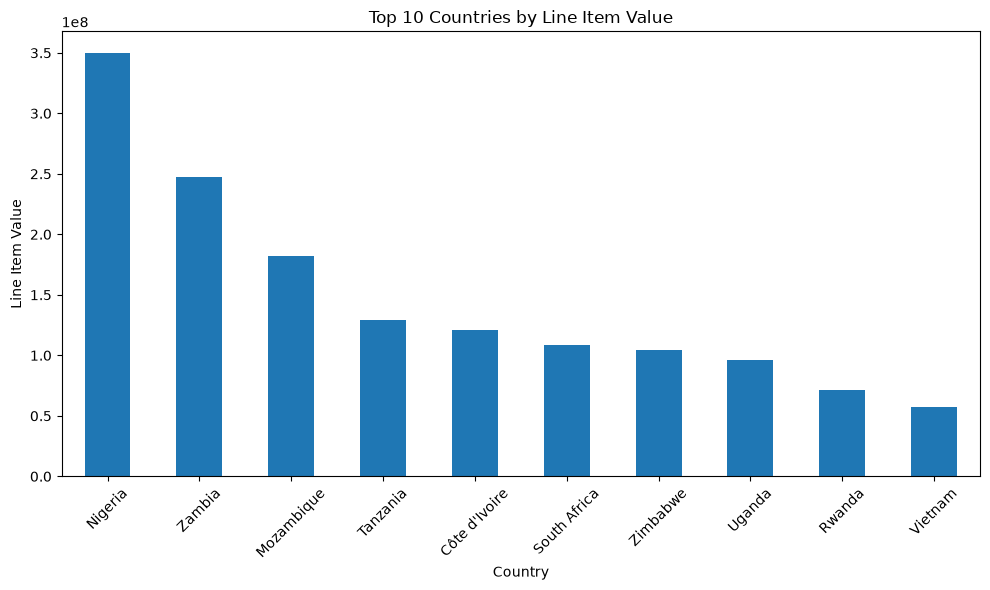

In [62]:
# Top 10 Countries by Line Item Value

top_countries = df.groupby("Country")["Line Item Value"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Line Item Value")
plt.xlabel("Country")
plt.ylabel("Line Item Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

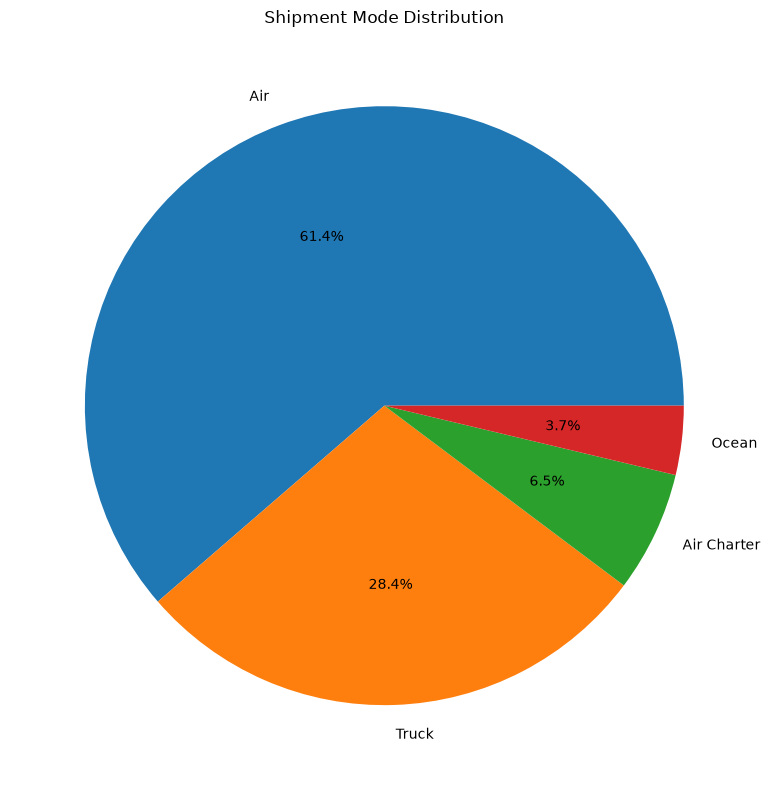

In [63]:
shipment_mode = df["Shipment Mode"].value_counts()

plt.figure(figsize=(8,8))

shipment_mode.plot(kind="pie", autopct="%1.1f%%")

plt.title("Shipment Mode Distribution")
plt.ylabel("")

plt.tight_layout()
plt.show()

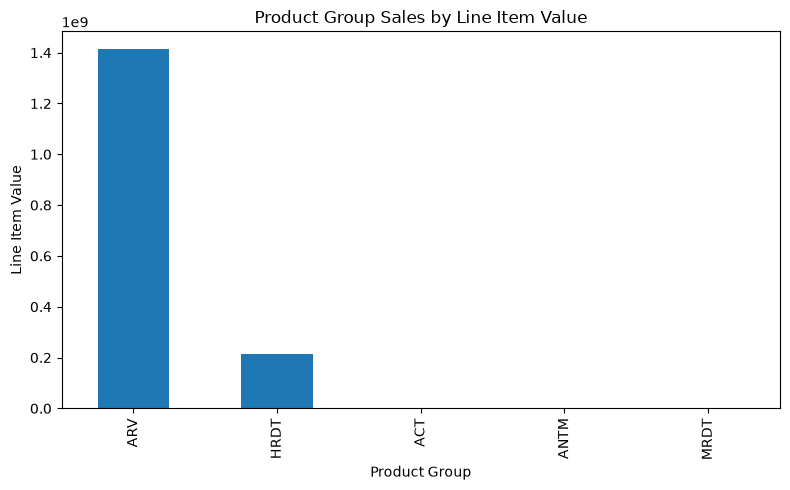

: 

In [ ]:
product_sales = df.groupby("Product Group")["Line Item Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

product_sales.plot(kind="bar")

plt.title("Product Group Sales by Line Item Value")
plt.xlabel("Product Group")
plt.ylabel("Line Item Value")

plt.tight_layout()
plt.show()